# Deep Diabetes Risk Demo\n
\n
This notebook reproduces the core workflow: preprocess data, train the Deep MLP, and generate evaluation plots/metrics.

## 1) Environment Setup

In [2]:
import os, sys, subprocess
ROOT = os.getcwd()
print('Current working directory:', ROOT)
print('Python:', sys.executable)

Current working directory: /Users/jonathanvigil/dev/deep-diabetes-risk
Python: /opt/anaconda3/bin/python


## 2) Preprocess Data\n
Runs `src/data_pipeline.py` to create `data_processed/train.pt`, `val.pt`, and `test.pt`.

In [3]:
subprocess.run([sys.executable, 'data_pipeline.py'], cwd='src', check=True)

Shape: (253680, 22)
   Diabetes_binary  HighBP  HighChol  CholCheck  ...  Sex   Age  Education  Income
0              0.0     1.0       1.0        1.0  ...  0.0   9.0        4.0     3.0
1              0.0     0.0       0.0        0.0  ...  0.0   7.0        6.0     1.0
2              0.0     1.0       1.0        1.0  ...  0.0   9.0        4.0     8.0
3              0.0     1.0       0.0        1.0  ...  0.0  11.0        3.0     6.0
4              0.0     1.0       1.0        1.0  ...  0.0  11.0        5.0     4.0

[5 rows x 22 columns]

Missing values:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0


CompletedProcess(args=['/opt/anaconda3/bin/python', 'data_pipeline.py'], returncode=0)

## 3) Train Deep MLP\n
Runs `src/deep_mlp.py` and saves the best model and test metrics in `src/results/`.

In [4]:
subprocess.run([sys.executable, 'deep_mlp.py'], cwd='src', check=True)

Using device: cpu
Class imbalance weight: 6.18x
Epoch   1/30  |  Train Loss: 0.916  |  Train Acc: 0.702  |  Val Loss: 0.881  |  Val AUC: 0.824  |  Val F1: 0.424  |  Val Recall: 0.827
Epoch   2/30  |  Train Loss: 0.880  |  Train Acc: 0.709  |  Val Loss: 0.877  |  Val AUC: 0.825  |  Val F1: 0.442  |  Val Recall: 0.784
Epoch   3/30  |  Train Loss: 0.873  |  Train Acc: 0.714  |  Val Loss: 0.874  |  Val AUC: 0.827  |  Val F1: 0.429  |  Val Recall: 0.826
Epoch   4/30  |  Train Loss: 0.870  |  Train Acc: 0.713  |  Val Loss: 0.874  |  Val AUC: 0.827  |  Val F1: 0.428  |  Val Recall: 0.830
Epoch   5/30  |  Train Loss: 0.867  |  Train Acc: 0.714  |  Val Loss: 0.871  |  Val AUC: 0.828  |  Val F1: 0.444  |  Val Recall: 0.781
Epoch   6/30  |  Train Loss: 0.866  |  Train Acc: 0.715  |  Val Loss: 0.872  |  Val AUC: 0.828  |  Val F1: 0.436  |  Val Recall: 0.809
Epoch   7/30  |  Train Loss: 0.864  |  Train Acc: 0.716  |  Val Loss: 0.873  |  Val AUC: 0.828  |  Val F1: 0.439  |  Val Recall: 0.807
Epoch  

CompletedProcess(args=['/opt/anaconda3/bin/python', 'deep_mlp.py'], returncode=0)

## 4) Evaluate Against Baselines and Plot Results\n
Runs `src/plot_results.py` to compute baseline metrics, print/save the metrics table, and generate figures.

In [5]:
subprocess.run([sys.executable, 'plot_results.py'], cwd='src', check=True)

Running baseline models...
Getting Deep MLP predictions...
Computing evaluation metrics table...

Evaluation Metrics (Baselines + Deep MLP)
Model               | Accuracy | Precision | Recall  | F1     | ROC-AUC  | Specificity | TP     | TN     | FP     | FN    
--------------------+----------+-----------+---------+--------+----------+-------------+--------+--------+--------+-------
Logistic Regression |   0.7334 |    0.3128 |  0.7631 | 0.4437 |   0.8216 |      0.7286 |   4046 |  23862 |   8888 |   1256
KNN                 |   0.8483 |    0.4128 |  0.2107 | 0.2790 |   0.7260 |      0.9515 |   1117 |  31161 |   1589 |   4185
Naive Bayes         |   0.7738 |    0.3223 |  0.5653 | 0.4105 |   0.7819 |      0.8075 |   2997 |  26447 |   6303 |   2305
Deep MLP            |   0.7009 |    0.2958 |  0.8304 | 0.4362 |   0.8299 |      0.6799 |   4403 |  22266 |  10484 |    899
Saved metrics table to results/model_metrics_table.txt
Generating plots...
All plots saved to results/


CompletedProcess(args=['/opt/anaconda3/bin/python', 'plot_results.py'], returncode=0)

## 5) Display Generated Plots

### metrics_comparison.png

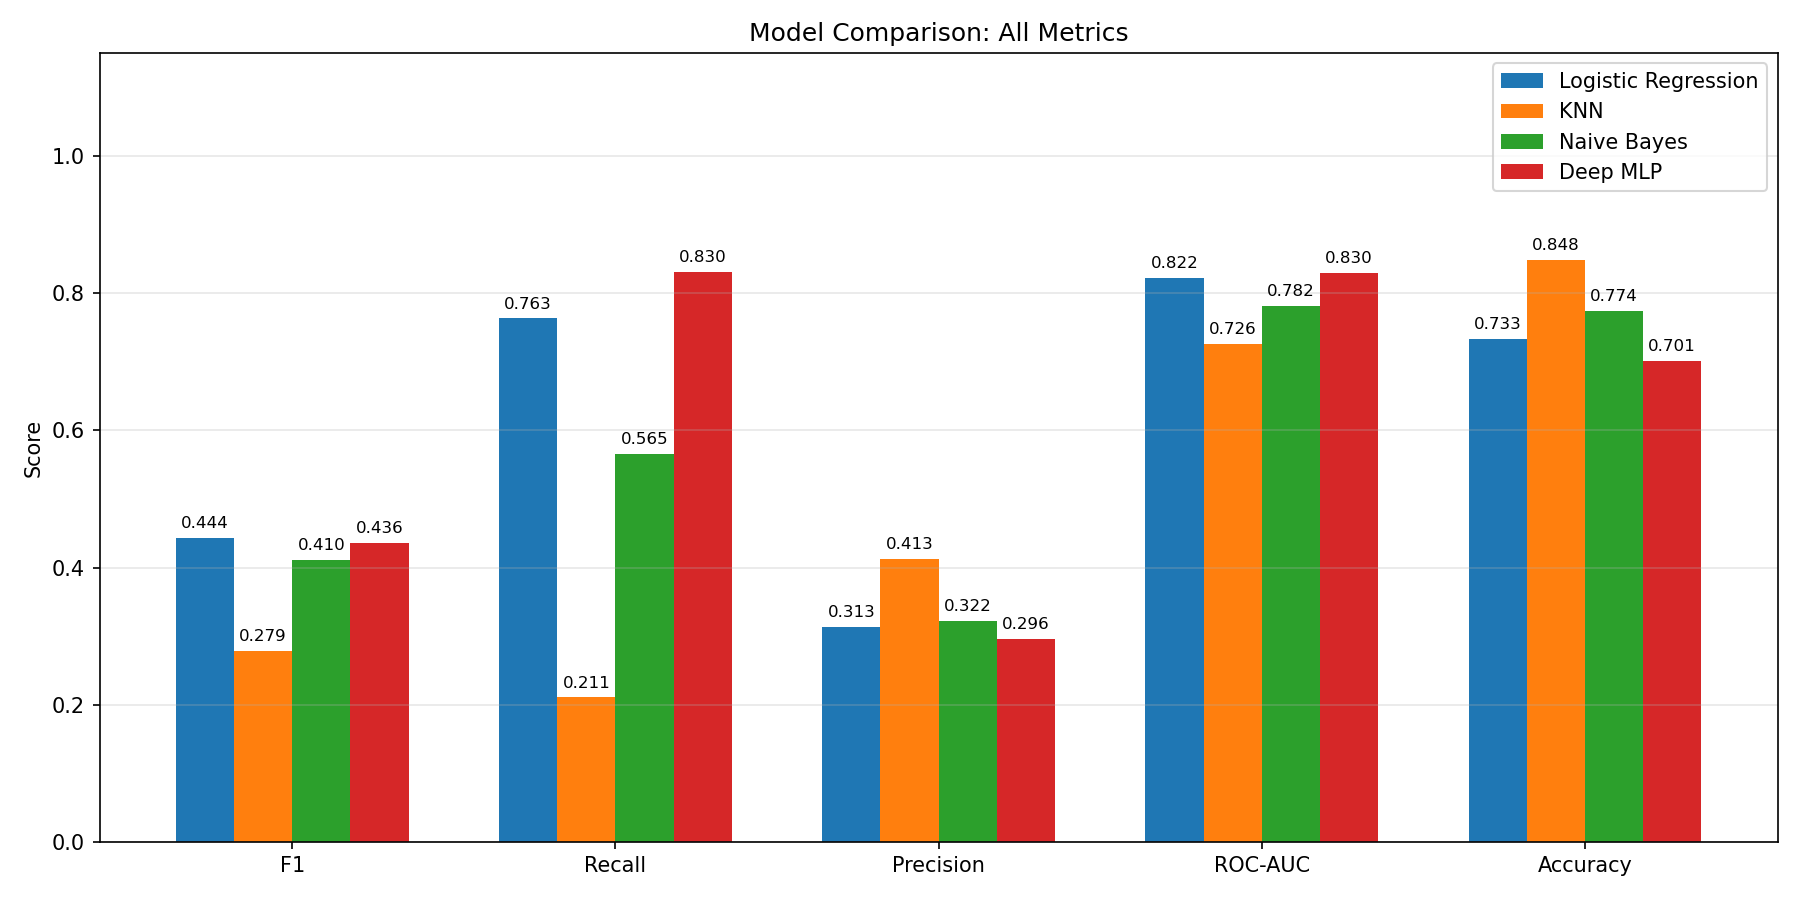

### confusion_matrix.png

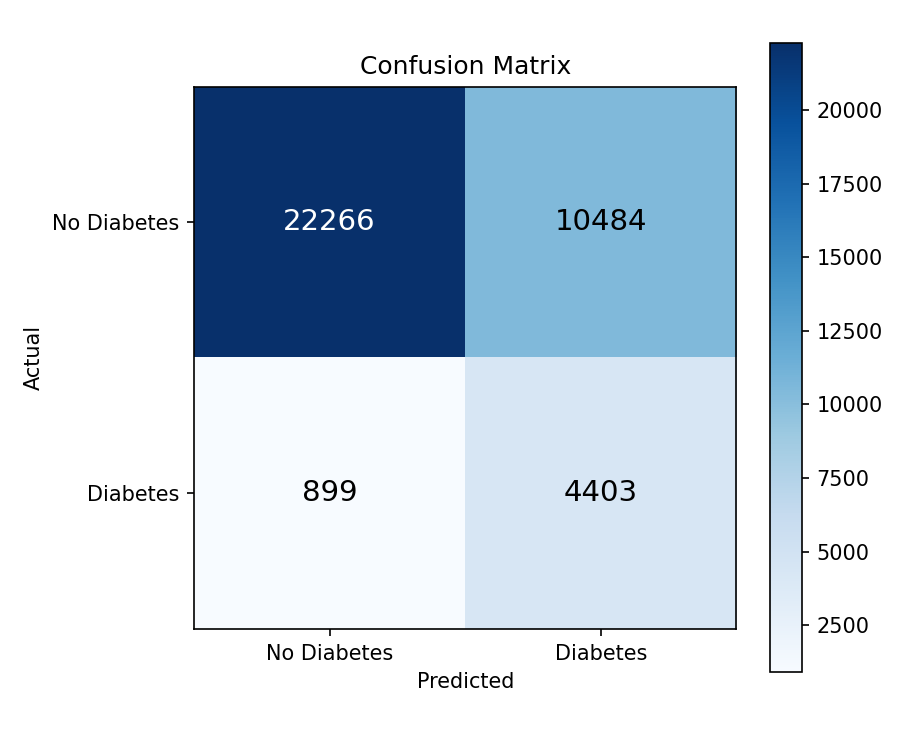

### feature_ablation.png

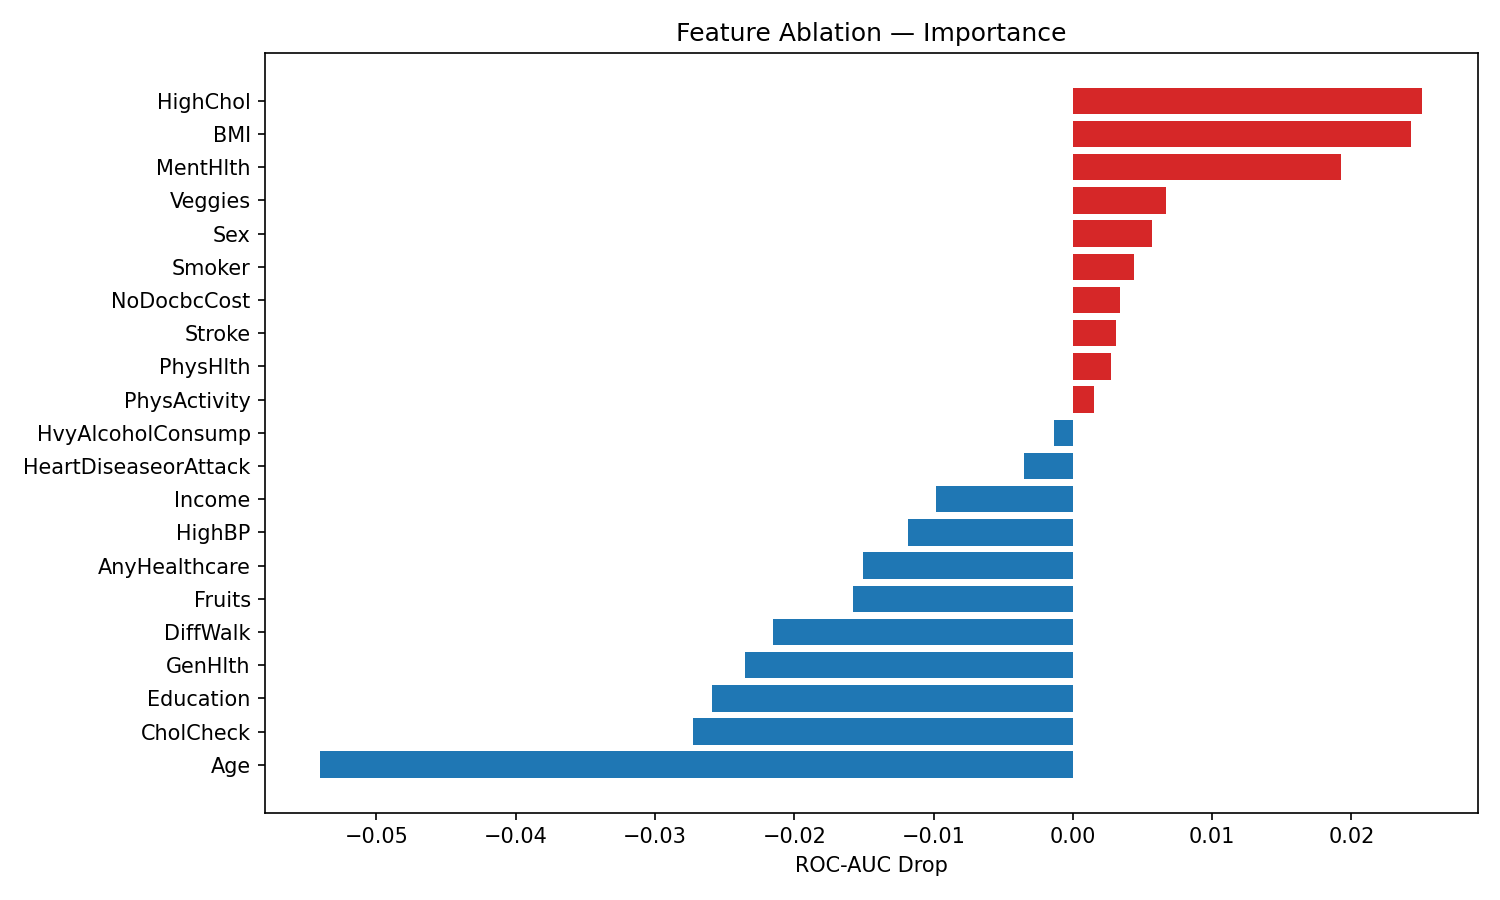

### latent_tsne.png

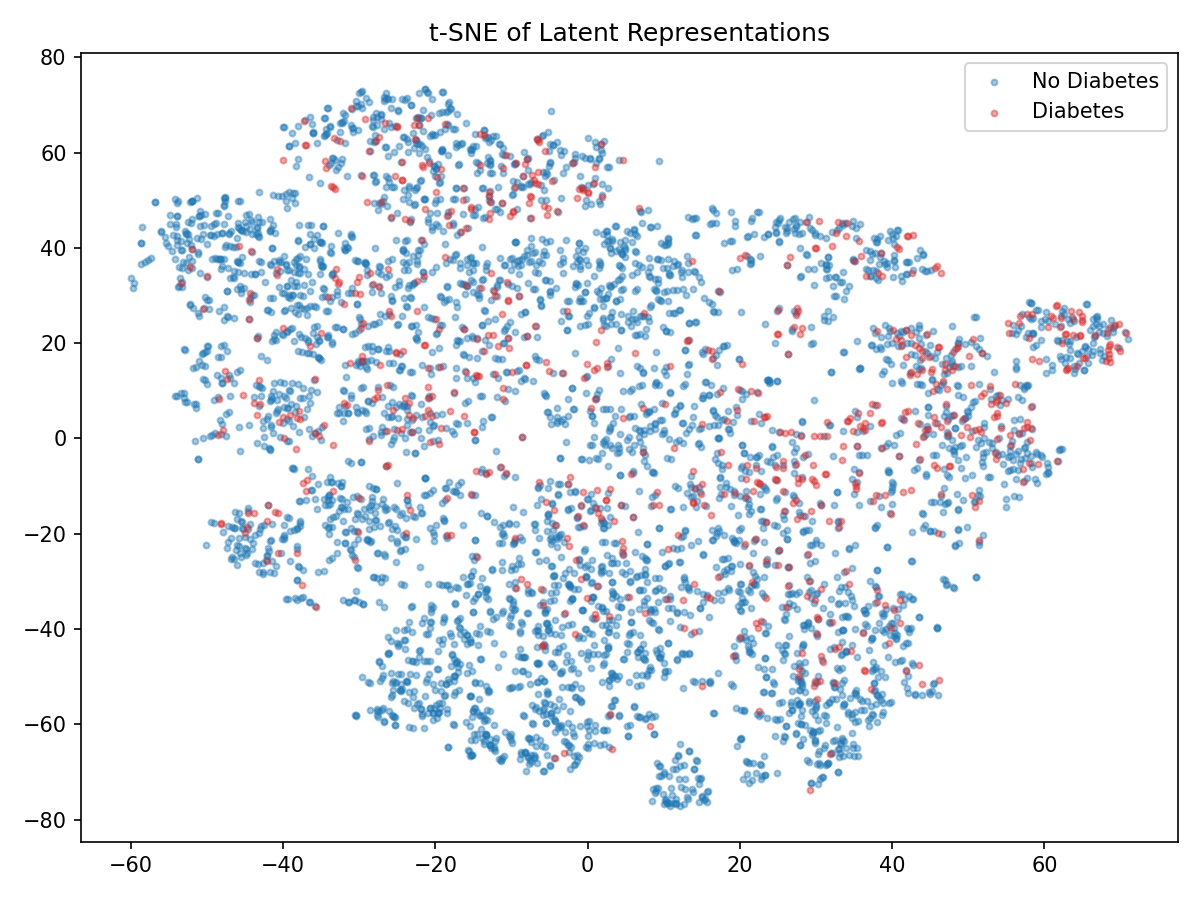

### calibration_all_models.png

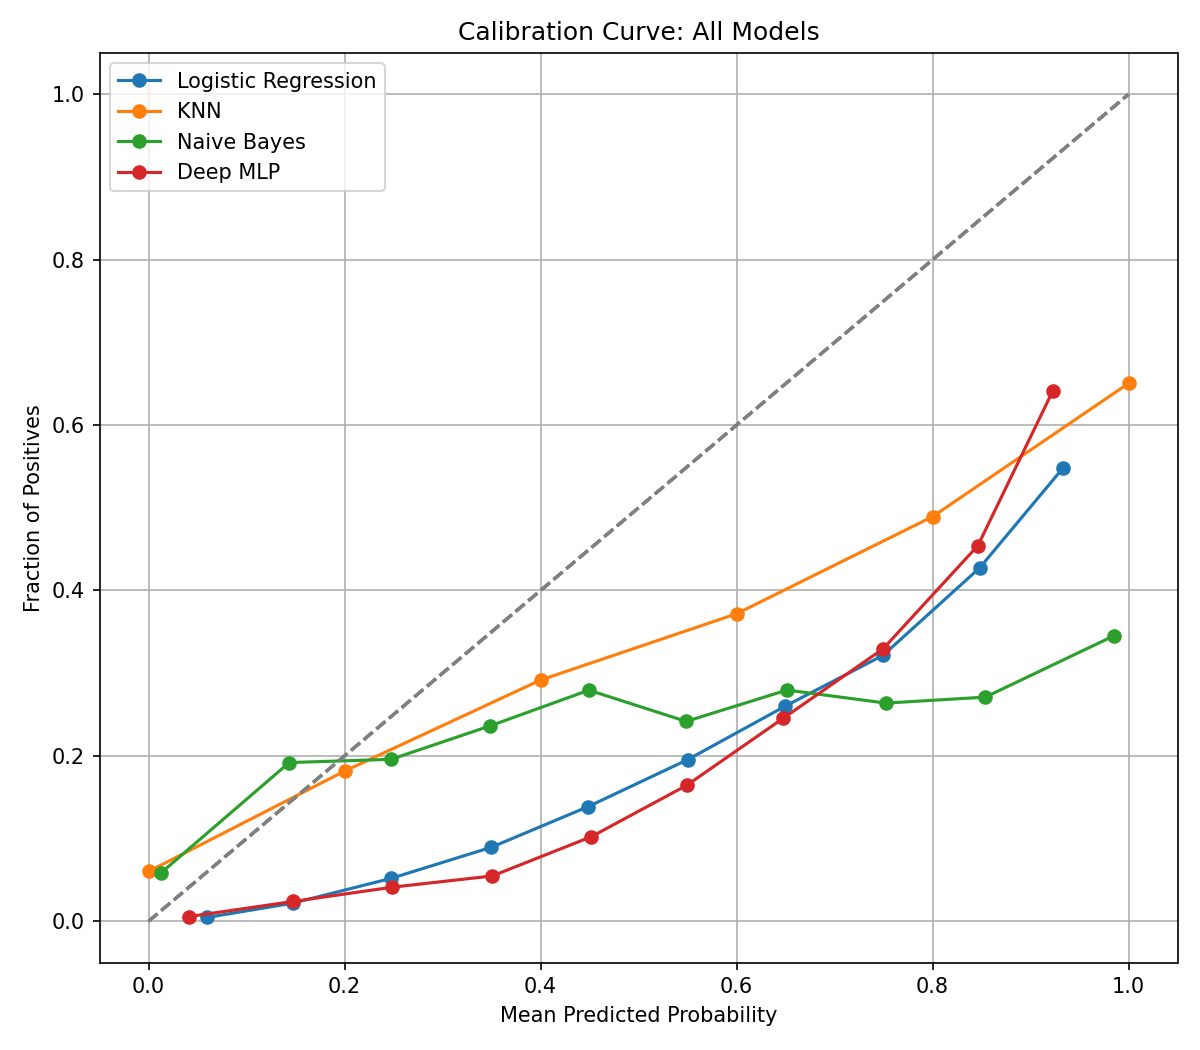

### roc_all_models.png

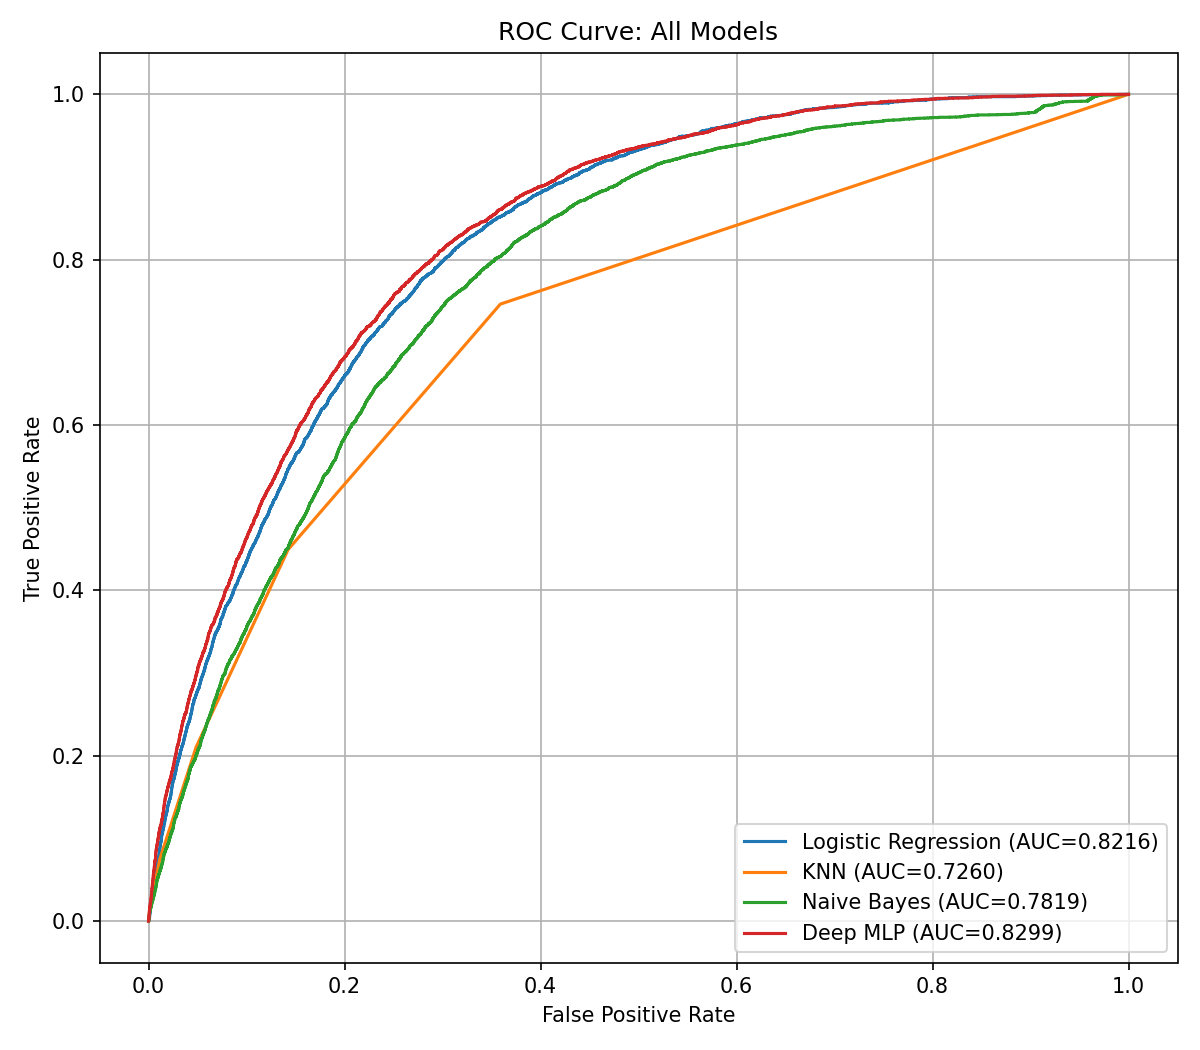

### pr_all_models.png

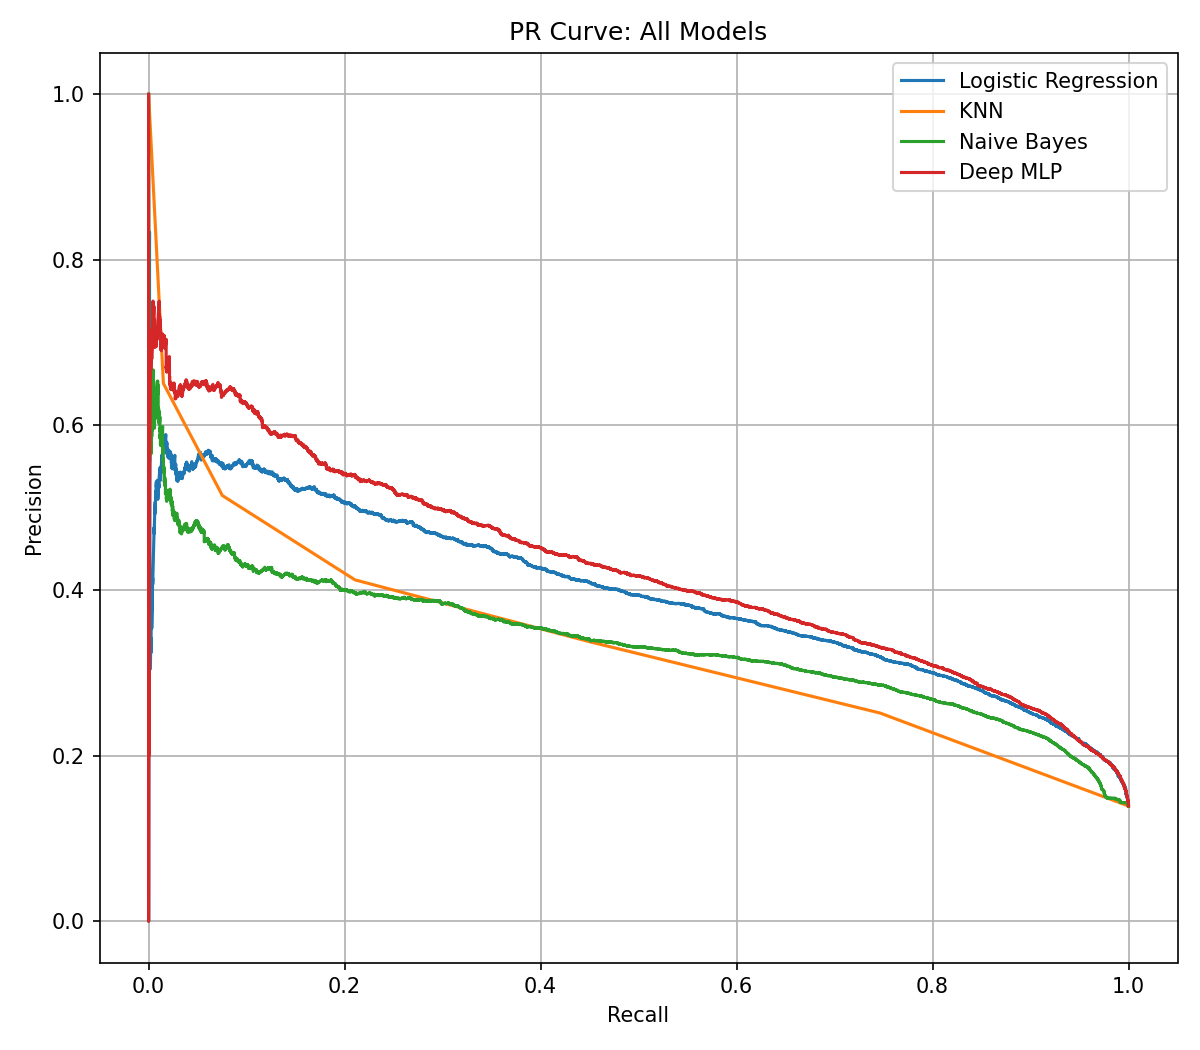

In [8]:
from pathlib import Path
from IPython.display import Image, display, Markdown

plot_paths = [
    Path('src/results/metrics_comparison.png'),
    Path('src/results/confusion_matrix.png'),
    Path('src/results/feature_ablation.png'),
    Path('src/results/latent_tsne.png'),
    Path('src/results/calibration_all_models.png'),
    Path('src/results/roc_all_models.png'),
    Path('src/results/pr_all_models.png'),
]

for path in plot_paths:
    if path.exists():
        display(Markdown(f"### {path.name}"))
        display(Image(filename=str(path)))
    else:
        print(f"Missing plot: {path}")